In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import *
import pickle

In [3]:
# Use GPU if it is avaialable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
test_df = pd.read_csv("Fashion_MNIST_dataset//fashion-mnist_test.csv").fillna(0)
train_df = pd.read_csv("Fashion_MNIST_dataset//fashion-mnist_train.csv").fillna(0)


y_train = train_df.label
y_train = torch.tensor(y_train.values, dtype=torch.long).to(device)

x_train = train_df.drop('label', axis=1)
x_train = torch.tensor(x_train.values, dtype=torch.float32).to(device)


y_test = test_df.label
y_test = torch.tensor(y_test.values, dtype=torch.long).to(device)

x_test = test_df.drop('label', axis=1)
x_test = torch.tensor(x_test.values, dtype=torch.float32).to(device)

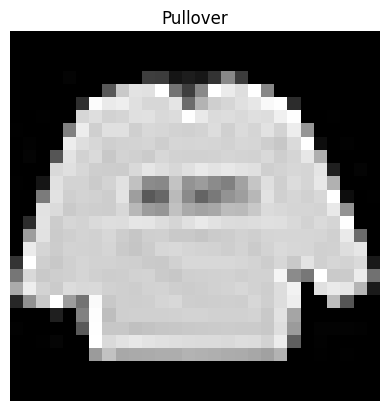

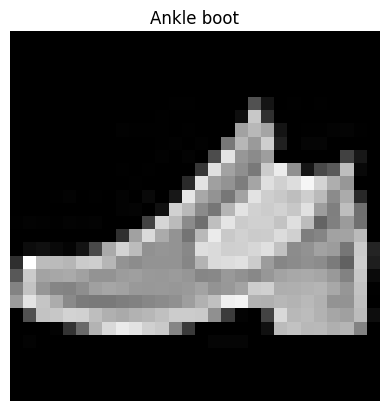

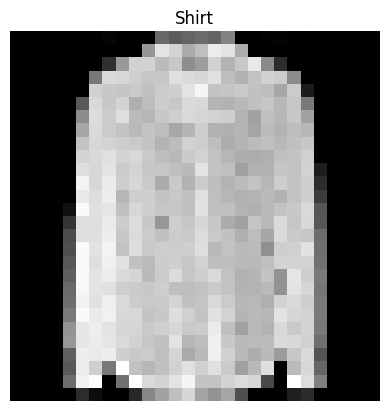

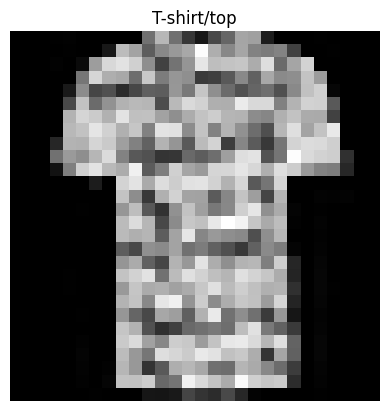

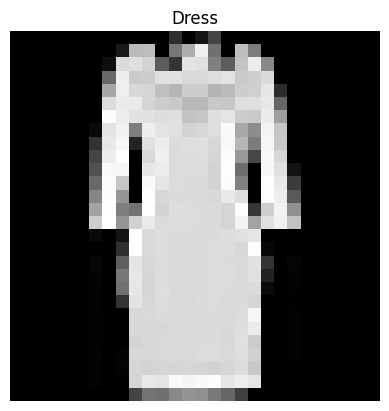

In [5]:
Labels = ["T-shirt/top" , "Trouser" , "Pullover" , "Dress" , "Coat" , "Sandal" , "Shirt" , "Sneaker" , "Bag" , "Ankle boot"]

# VISUALISING IMAGES
for i,j in zip(x_train[:5],y_train[:5]):
    i1 = i.cpu().reshape(28,28)
    plt.imshow(i1 ,cmap="gray")
    plt.title(label=Labels[j.item()])
    plt.axis("off")
    plt.show()

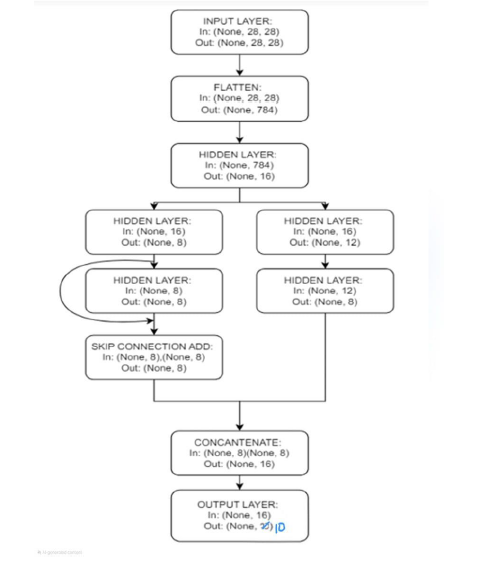

In [6]:
# Model as given in the diagram

# flatten layer isn't needed as the data is already in form of vector rather than a matrix
class FMNIST(nn.Module):
    def __init__(self):
        super(FMNIST, self).__init__()
        self.fc1 = nn.Linear(784 , 16)

        self.fc2_1 = nn.Linear(16 , 8)
        self.fc3_1 = nn.Linear(8 , 8)

        self.fc2_2 = nn.Linear(16 , 12)
        self.fc3_2 = nn.Linear(12 , 8)

        self.fc4 = nn.Linear(16 , 10)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)

        x1_1 = self.fc2_1(x)
        x1_1 = torch.relu(x1_1)
        x1_2 = self.fc3_1(x1_1)
        x1_2 = torch.relu(x1_2)
        x1 = x1_1 + x1_2

        x2 = self.fc2_2(x)
        x2 = torch.relu(x2)
        x2 = self.fc3_2(x2)
        x2 = torch.relu(x2)

        x = torch.cat((x1, x2), dim=1)
        x = self.fc4(x)
        # wanted to add softmax to convert it into a proper probability distribution but it wasn't given in the model 
        return x
    
    def evaluate(self, X, y):
        self.eval()
        with torch.no_grad():
            y_pred = self.forward(X)
            y_pred = torch.argmax(y_pred, dim=1)
        acc = accuracy_score(y.cpu() , y_pred.cpu())
        prec = precision_score(y.cpu() , y_pred.cpu() , average="macro")
        rec = recall_score(y.cpu() , y_pred.cpu() , average="macro")
        f1 = f1_score(y.cpu() , y_pred.cpu() , average="macro")
        return acc , prec , rec , f1 , y_pred

In [7]:
# Seed so that there is no randomness when we continously run the prgram
torch.manual_seed(12)
Model = FMNIST().to(device)
loss_vals = []      # will save all loss values to be plotted later
accuracy_vals = []  # will save all accuracy values to be plotted later

epochs = 200    # how many iteration will the model run for
batch_size = 1000   # in each iteration data will be devided into chunks of which length
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(Model.parameters(), lr=1e-4 , weight_decay= 1e-2)

for epoch in range(epochs):
    Model.train()
    total_loss = 0

    for i in range(0,len(x_train),batch_size):
        y_pred = Model.forward(x_train[i:i+batch_size])
        loss = loss_fn(y_pred, y_train[i:i+batch_size])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
    with torch.no_grad():
        y_pred = torch.argmax(Model.forward(x_test),dim=1)  # gives what the prediction is instead of a probability destribution type thing
        accuracy = torch.mean((y_pred == y_test).float())   #how many values are correct out of all values tested
    loss_vals.append(total_loss/(len(x_train)//batch_size))
    accuracy_vals.append(accuracy)
    if((epoch+1)%(epochs//10))==0:
        print(f"Epoch : {epoch+1}\tLoss : {loss_vals[-1]}\tAccuracy : {accuracy.item()*100}%")

Epoch : 20	Loss : 0.5130768080552419	Accuracy : 82.35999941825867%
Epoch : 40	Loss : 0.42715512216091156	Accuracy : 84.9299967288971%
Epoch : 60	Loss : 0.3848586549361547	Accuracy : 85.65999865531921%
Epoch : 80	Loss : 0.35662080595890683	Accuracy : 86.05999946594238%
Epoch : 100	Loss : 0.33547599116961163	Accuracy : 86.52999997138977%
Epoch : 120	Loss : 0.3180999328692754	Accuracy : 86.76999807357788%
Epoch : 140	Loss : 0.3040522331992785	Accuracy : 87.00999617576599%
Epoch : 160	Loss : 0.2927482311924299	Accuracy : 87.02999949455261%
Epoch : 180	Loss : 0.2836356381575266	Accuracy : 86.93999648094177%
Epoch : 200	Loss : 0.2759490206837654	Accuracy : 87.10999488830566%


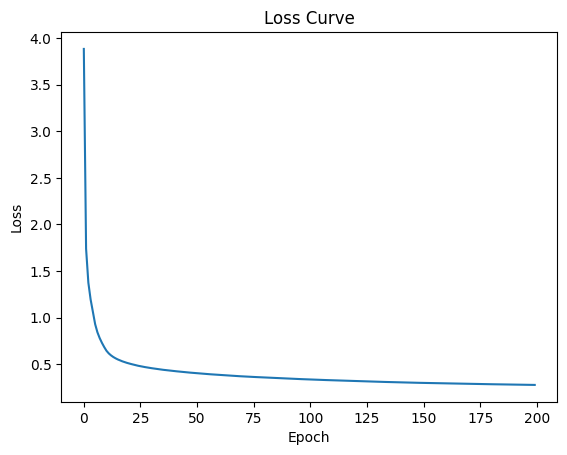

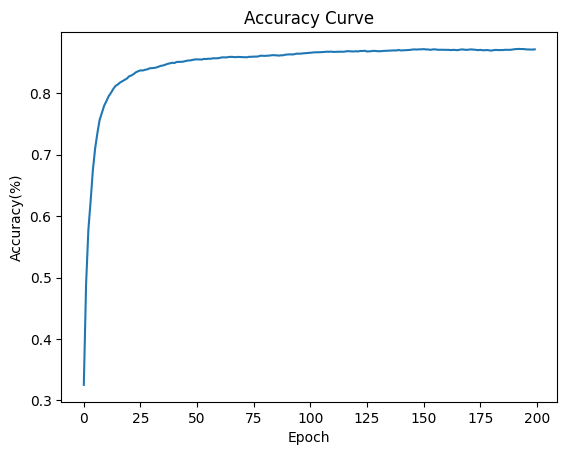

In [8]:
# Loss Curve
plt.plot(loss_vals)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy Curve
plt.plot(torch.tensor(accuracy_vals).cpu())
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy(%)")
plt.show()

In [9]:
#Fashion_MNIST TESTING
accuracy , precision , recall , f1 , y_pred = Model.evaluate(x_test,y_test)


print(f"Accuracy : {accuracy*100}%")
print(f"Precision : {precision*100}%")
print(f"Recall : {recall}")
print(f"F1 Score : {f1}")

Accuracy : 87.11%
Precision : 87.03186794891273%
Recall : 0.8711
F1 Score : 0.8698098006395982


In [10]:
# Saving Model Weights
weights = Model.state_dict()
with open("Model_weights.pkl","wb") as f:
    pickle.dump(weights , f)

# Saving Answers given by model, actual answer and if it was true or not 
df = pd.DataFrame({"Labels" : [Labels[i] for i in y_test] , "Predicted" : [Labels[i] for i in y_pred] , "Correct" : ["Yes" if y_test[i] == y_pred[i] else "NO" for i in range(len(y_test))]})
df.to_csv("Submission.csv")